# Cohort Data Creation

In [1]:
import pandas as pd
from LabData.DataLoaders.GutMBLoader import GutMBLoader
from LabData.DataLoaders.SubjectLoader import SubjectLoader
from LabData.DataLoaders.DietLoggingLoader import DietLoggingLoader
from LabData.DataLoaders.LifeStyleLoader import LifeStyleLoader
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader
from LabData.DataAnalyses.TenK_Trajectories.utils import get_diet_logging_around_stage
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
SPECIES = 'segal_species' # 'segal_species' or 'mpa_species'

# Study configuration
study_ids = [15]  # [15] for Australian cohort, ['AUS'] for AUS
# Map study_ids to study name for file naming
study_name_map = {15: 'AU15', 'AUS': 'AUS'}
study_name = study_name_map.get(study_ids[0] if isinstance(study_ids[0], int) else study_ids[0], f'study_{study_ids[0]}')

min_col_present_frac = 0.05

In [3]:
diet_mb_10k = pd.read_pickle(home_path + f"data/{SPECIES}/diet_mb.pkl")
with open(home_path + f'data/{SPECIES}/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features_10k, all_features_10k, targets_10k = loaded_lists
with open(home_path + f'data/{SPECIES}/scaler.pkl', 'rb') as scaler_file:
        scaler_10k = pickle.load(scaler_file)
diet_mb_10k

,Acorn squash,Alfalfa sprouts,Almond Beverage,Almond flour,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple Vinegar,...,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity,GMWI2_score,modified_HACK_top17_score
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.016416,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000,189,3.75,0.930216,96.28125
10K_1001201093,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013895,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000,150,3.34,0.881661,157.28125
10K_1002254441,0.0,0.0,0.0,0.0,0.0,0.081238,0.0,0.000000,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-2.383721,-4.00000,250,4.25,0.820586,205.53125
10K_1003113258,0.0,0.0,0.0,0.0,0.0,0.002048,0.0,0.008929,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-3.806766,-4.00000,262,4.29,1.025713,147.28125
10K_1007330152,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-1.937423,-2.98186,194,3.75,1.202788,92.56250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9996884777,0.0,0.0,0.0,0.0,0.0,0.002401,0.0,0.000000,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-3.832439,-3.78628,257,4.01,0.783450,153.59375
10K_9998420917,0.0,0.0,0.0,0.0,0.0,0.019995,0.0,0.018783,0.000000,0.0,...,-4.0,-4.0,-4.0,-2.564519,-2.439687,-4.00000,264,4.25,0.781873,130.71875
10K_9998635752,0.0,0.0,0.0,0.0,0.0,0.001607,0.0,0.011305,0.000000,0.0,...,-4.0,-4.0,-4.0,-4.000000,-2.996193,-4.00000,183,3.28,1.176277,137.21875


In [4]:
def explore_columns(df):
    for column in df.columns:
        print(column)
        print(df[column].value_counts())

# study_ids is defined in cell 2
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=study_ids)
subjects_df = subjects_data.df
print(subjects_df)

                             StudyTypeID  city country  gender month_of_birth  \
RegistrationCode Date                                                           
3002243          NaT                15.0  None      AU     NaN           None   
3002905          2023-01-01         15.0  None      AU     0.0           None   
3006146          NaT                15.0  None      AU     NaN           None   
3014896          2020-01-01         15.0  None      AU     1.0           None   
3015169          NaT                15.0  None      AU     NaN           None   
...                                  ...   ...     ...     ...            ...   
3974179          2020-01-01         15.0  None      AU     1.0           None   
3976912          2020-01-01         15.0  None      AU     0.0           None   
3987074          NaT                15.0  None      AU     NaN           None   
3991756          NaT                15.0  None      AU     NaN           None   
3993066          NaT        

## Load Microbiome Data

In [5]:
gut_bacteria = GutMBLoader().get_data(SPECIES, subjects_df=subjects_df, study_ids=study_ids,
                                groupby_reg='first', 
                                genotek_vals=[1], min_col_val=1e-4, take_log=True)
gut_bacteria_df = gut_bacteria.df.dropna(axis=1, how='all')
gut_bacteria_df.columns = gut_bacteria_df.columns.str.replace('s__', '')
# with open(home_path + f'data/{species}/my_lists.pkl', 'rb') as file:
#         loaded_lists = pickle.load(file)
# base_features, all_diet_features, targets = loaded_lists
gut_bacteria_df = gut_bacteria_df[targets_10k]



gut_bacteria_df.head(3)

/home/tomerse/.local/lib/python3.7/site-packages/pandas/core/frame.py:6402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  key,


species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,-4.0,-4.0,-4.00000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.0,-4.000000,...,-4.0,-4.0,-4.0,-2.645027,-4.0,-4.0,-4.0,-4.0,-3.055171,-4.0
131323320780891_v2_fullrun,-4.0,-4.0,-4.00000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.0,-3.042893,...,-4.0,-4.0,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.0,-2.556423,-4.0
131353237430853_v2_fullrun,-4.0,-4.0,-2.13568,-2.508924,-4.0,-4.0,-4.0,-4.0,-4.0,-4.000000,...,-4.0,-4.0,-4.0,-3.616712,-4.0,-4.0,-4.0,-4.0,-2.522924,-4.0


In [6]:
gut_bacteria_df.shape

(150, 724)

In [7]:
gut_bacteria_df

species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-2.645027,-4.0,-4.0,-4.0,-4.000000,-3.055171,-4.000000
131323320780891_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.042893,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.556423,-4.000000
131353237430853_v2_fullrun,-4.0,-4.00000,-2.13568,-2.508924,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-3.616712,-4.0,-4.0,-4.0,-4.000000,-2.522924,-4.000000
131393599090217_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.835409,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.784588,-4.000000
131403088478160_v2_fullrun,-4.0,-4.00000,-4.00000,-2.529034,-4.0,-4.000000,-4.0,-2.149378,-4.000000,-4.000000,...,-4.0,-3.565438,-2.228209,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-3.065981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898313_v2_fullrun,-4.0,-4.00000,-3.20460,-3.089961,-4.0,-2.486368,-4.0,-2.397183,-4.000000,-4.000000,...,-4.0,-4.000000,-3.348478,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3911362_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-3.820609,-2.978476,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.212831,-4.000000
39244661501_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-2.623527,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-2.727943,-2.318047,-4.000000


In [8]:
gut_bacteria.df_metadata

,RegistrationCode,GenesetMapCount,HGMappedRC,MPAMapCount,Nextera,PE,PostBBDRC,PostHGFRC,PostQCRC,PostTrimRC,...,StudyTypeID4,StudyTypeID7,gender,month_of_birth,StudyTypeID6,StudyTypeID9,yob,StudyTypeID2,StudyTypeID8,us_state
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,3668395,NaN,1241.0,NaN,None,False,8267486.0,9236289.0,9241475.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,1952.0,NaN,NaN,None
131323320780891_v2_fullrun,3320780,NaN,2066.0,NaN,None,False,NaN,11018163.0,11026254.0,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,1952.0,NaN,NaN,None
131353237430853_v2_fullrun,3237430,NaN,5539.0,NaN,None,False,10276435.0,9800605.0,9809742.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,1965.0,NaN,NaN,None
131393599090217_v2_fullrun,3599090,NaN,8679.0,NaN,None,False,NaN,9457472.0,9466270.0,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,1954.0,NaN,NaN,None
131403088478160_v2_fullrun,3088478,NaN,2397.0,NaN,None,False,7720971.0,4956349.0,4965147.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,1955.0,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898313_v2_fullrun,3898313,NaN,3024.0,NaN,None,False,8430159.0,9613356.0,9616380.0,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,1959.0,NaN,NaN,None
3911362_v2_fullrun,3911362,NaN,2327.0,NaN,None,False,9247817.0,9555907.0,9560174.0,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,1972.0,NaN,NaN,None
39244661501_v2_fullrun,3924466,NaN,10427.0,NaN,None,False,8769763.0,9557587.0,9568665.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,1974.0,NaN,NaN,None


In [9]:
gut_bacteria_df = gut_bacteria_df.join(gut_bacteria.df_metadata[['RegistrationCode', 'Date']]).set_index(['RegistrationCode', 'Date'])
gut_bacteria_df.tail(20)

,,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,Date,,,,,,,,,,,,,,,,,,,,,
3585617,2021-04-12 00:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.152386,...,-1.408836,-2.149620,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-2.916684,-2.069356
3633119,2020-11-15 00:00:00,-4.000000,-4.000000,-1.987950,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-1.862447,...,-4.000000,-3.180921,-4.000000,-3.535495,-4.000000,-4.0,-4.0,-4.000000,-3.884935,-4.000000
3645100,2022-10-02 15:55:18,-3.835749,-2.280764,-4.000000,-1.921492,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-1.590507,...,-4.000000,-2.484126,-4.000000,-3.288312,-4.000000,-4.0,-4.0,-4.000000,-3.314707,-4.000000
3701040,2022-12-06 15:26:01,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-3.460268,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3737293,2021-04-15 17:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-1.406925,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3743874,2020-07-15 00:00:00,-4.000000,-4.000000,-4.000000,-3.863339,-4.0,-4.000000,-4.0,-1.777088,-4.000000,-4.000000,...,-4.000000,-2.771693,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-3.895030,-4.000000
3759637,2024-07-09 13:01:26,-4.000000,-4.000000,-4.000000,-1.741657,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-3.065293,-4.000000,-4.0,-4.0,-2.708507,-3.321495,-4.000000
3782350,2020-07-15 00:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3803599,2019-02-07 14:46:23,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-3.094938,-4.000000,-4.0,-4.0,-4.000000,-2.540269,-4.000000


In [10]:
gut_bacteria_df_date = gut_bacteria_df.copy()

In [11]:
# Keep only baseline data (first test per person)
gut_bacteria_df = gut_bacteria_df.groupby(level=0).first().sort_index()

gut_bacteria_df

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.051407,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876970,-4.000000
3002905,-3.468552,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.11037,-3.778471,-2.991748,...,-4.0,-4.000000,-4.000000,-4.000000,-3.374288,-4.0,-4.0,-4.0,-3.774239,-4.000000
3006146,-4.000000,-4.000000,-4.0,-1.867471,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.157131
3014896,-1.806460,-2.910969,-4.0,-2.341247,-4.0,-4.0,-4.0,-4.00000,-4.000000,-1.498241,...,-4.0,-4.000000,-2.620554,-3.401376,-4.000000,-4.0,-4.0,-4.0,-3.790802,-4.000000
3026711,-4.000000,-4.000000,-4.0,-2.035487,-4.0,-4.0,-4.0,-4.00000,-4.000000,-1.754431,...,-4.0,-2.940176,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-2.091640,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.201972
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
3962829,-4.000000,-4.000000,-4.0,-1.760109,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-2.270806,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000


In [12]:
# Normalize by row.

# Step 1: Convert to normal scale
gut_bacteria_df_normal = 10 ** gut_bacteria_df

# Step 2: Mask of values that are NOT 0.0001
mask = gut_bacteria_df_normal != 0.0001

# Step 3: Row-wise sum of the non-0.0001 values
non_floor_sum = gut_bacteria_df_normal.where(mask).sum(axis=1)

# Step 4: Normalize ONLY the non-0.0001 values, keep 0.0001 unchanged
gut_bacteria_df_normal = gut_bacteria_df_normal.where(~mask, gut_bacteria_df_normal.div(non_floor_sum, axis=0))

# Step 5: Convert back to log10
gut_bacteria_df_log = np.log10(gut_bacteria_df_normal)
gut_bacteria_df = gut_bacteria_df_log
gut_bacteria_df

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.0,-4.000000,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-4.0,-4.000000,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-4.0,-2.936998,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-2.053007,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-2.264907,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000


In [13]:
# Keep only baseline microbiome data
baseline_mb = gut_bacteria_df#.reset_index(level=[1], drop=True)

In [14]:
gut_bacteria_df_col = gut_bacteria.df_columns_metadata
# View 5 most common bacteria
gut_bacteria_df_col[gut_bacteria_df_col['Unnamed: 0'].isin(["Rep_485", "Rep_609", "Rep_477", "Rep_449", "Rep_231"])]

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,sSGB,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new
fBin__45|gBin__157|sBin__231,Rep_231,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri,231.0,157.0,...,1626,1238,579,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri_B
fBin__73|gBin__324|sBin__449,Rep_449,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus,449.0,324.0,...,1814,1353,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus
fBin__73|gBin__337|sBin__477,Rep_477,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,477.0,337.0,...,1836,1366,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis
fBin__73|gBin__341|sBin__485,Rep_485,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown,485.0,341.0,...,1854,1371,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown
fBin__86|gBin__419|sBin__609,Rep_609,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis,609.0,419.0,...,2318,1686,673,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis


In [15]:
gut_bacteria_df_col.to_pickle(home_path + f"data/mb_names_{study_name.lower()}.pkl")

In [16]:
gut_bacteria_df_meta = gut_bacteria.df_metadata
print(gut_bacteria_df_meta.head())
# Check that there's only one mb test per person
gut_bacteria_df_meta.RegistrationCode.value_counts()

                           RegistrationCode  GenesetMapCount  HGMappedRC  \
SampleName                                                                 
131303668395536_v2_fullrun          3668395              NaN      1241.0   
131323320780891_v2_fullrun          3320780              NaN      2066.0   
131353237430853_v2_fullrun          3237430              NaN      5539.0   
131393599090217_v2_fullrun          3599090              NaN      8679.0   
131403088478160_v2_fullrun          3088478              NaN      2397.0   

                            MPAMapCount Nextera     PE   PostBBDRC  \
SampleName                                                           
131303668395536_v2_fullrun          NaN    None  False   8267486.0   
131323320780891_v2_fullrun          NaN    None  False         NaN   
131353237430853_v2_fullrun          NaN    None  False  10276435.0   
131393599090217_v2_fullrun          NaN    None  False         NaN   
131403088478160_v2_fullrun          NaN    None

3668395    1
3903198    1
3042146    1
3074002    1
3102388    1
          ..
3165097    1
3856705    1
3002243    1
3002905    1
3976912    1
Name: RegistrationCode, Length: 150, dtype: int64

### Alpha diversity targets

In [17]:
# Richness
def richness(row):
    filtered = row[row > -4]
    return len(filtered)

baseline_mb['Richness'] = baseline_mb.apply(richness, axis=1)
baseline_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000,112
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.000000,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000,226
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790,183
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-4.000000,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000,193
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-2.936998,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-2.053007,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339,120
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,39
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-2.264907,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,121


In [18]:
# Shannon Diversity
def shannon(row):
    filtered = row[row > -4]
    filtered = filtered.drop("Richness")
    
    rel_abundance = 10 ** filtered
    ln_rel_abundance = np.log(rel_abundance.replace(0, 1))
    product = rel_abundance * ln_rel_abundance
    ans = -1 * product.sum()
    return round(float(ans), 2)

baseline_mb['Shannon_diversity'] = baseline_mb.apply(shannon, axis=1)
baseline_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000,112,1.72
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000,226,4.06
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790,183,3.85
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000,193,3.80
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,131,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339,120,2.94
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,39,2.41
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,121,3.27


In [19]:
diversity_targets = ['Richness', 'Shannon_diversity']

## Load Diet Data

In [20]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/david_colab/my_lists_diet.pkl', 'rb') as file:
            loaded_lists = pickle.load(file)
base_features, all_diet_features = loaded_lists

In [21]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/food_shortnames.pkl', 'rb') as file:
    food_shortnames = pickle.load(file)
food_shortnames

Index(['Acorn squash', 'Alfalfa sprouts', 'Almond Beverage', 'Almond flour',
       'Almond spread', 'Almonds', 'Amba', 'Apple', 'Apple Cake',
       'Apple Vinegar',
       ...
       'Yellow pepper', 'Yogurt', 'Zaatar', 'Zucchini', 'Zucchini Patties',
       'black pepper', 'dried tomato spread', 'emmer wheat bread', 'ginger',
       'kale'],
      dtype='object', name='shortname_eng', length=570)

In [22]:
# dll = DietLoggingLoader()
# dlld = dll.get_data(study_ids=15, stage='baseline')
# # log = get_diet_logging_around_stage(dlld.df, delta_before=2, delta_after=14)
# log = dlld.df.reset_index()
# log = log.set_index(['RegistrationCode','Date','food_id'])
# print(log.head(10))
# log.shape

In [23]:
# log_date = dll.add_new_nutrients(log)
# log_date

In [24]:
diet_aus = pd.read_csv('/net/mraid20/ifs/wisdom/segal_lab/genie/LabData/Analyses/nastya/diet_predictions/nutr_full_clean_aus.csv', index_col=0)
diet_aus

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,8.363929,0.013355,0.039111,0.381106,1.377526,3.384739,0.548392,5.685655,22.196631,0.070205,...,5.486042,1404.146294,35.161784,4.051402,1044.084451,0.194450,64.233929,5.095714,2.738286,2722.412408
3002905,0.409091,0.002396,0.032473,0.306095,0.589051,2.393944,0.442477,5.479781,20.810984,0.027771,...,5.120025,1132.498702,24.698819,2.075081,1967.868918,0.613236,126.701273,13.974391,9.433636,2446.747244
3014896,0.000000,0.049767,0.062829,0.977160,0.547410,2.293406,0.640618,3.570429,16.690681,0.021976,...,5.213123,536.987756,30.500565,1.590451,774.692329,0.066618,23.011714,4.562714,10.840800,2576.054069
3026711,19.982143,0.000268,0.077810,0.236986,0.377155,1.303912,0.315579,5.148032,15.735059,0.028428,...,3.891844,463.258667,13.430793,1.168945,510.709144,1.162232,60.523095,0.857143,2.862929,1943.021926
3031986,0.000000,0.026846,0.082046,0.794360,0.833545,1.258857,0.298697,3.648543,13.145782,0.080468,...,6.300906,2736.024810,12.902716,0.995391,798.455810,0.576743,9.756333,47.864217,0.455769,1619.096114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,0.082878,1.690744,6.396467,3.583500,1.509483,0.427188,3.488478,18.607744,0.006176,...,2.128947,684.384439,12.756778,1.189192,480.563518,0.128322,59.518889,0.606222,0.000000,1877.124296
3944264,7.375385,0.006818,0.088382,0.579965,0.737116,1.739762,0.388671,3.271094,12.662036,0.019885,...,4.697333,496.616045,17.103716,1.561172,782.223461,0.401192,147.052462,1.073037,8.976688,2004.746895
3962829,6.041177,0.020203,0.002552,2.075162,2.427388,1.991559,0.448299,1.018039,13.960442,0.052568,...,3.471668,269.164314,19.312840,0.642868,427.182928,0.383271,28.528431,0.280059,0.742332,1278.707050


In [25]:
nutr_list = diet_aus.columns
nutr_list

Index(['Sugar alcohols', 'SFA 13:0', 'Tocotrienol, delta',
       'Tocotrienol, gamma', 'Tocotrienol, alpha',
       'Fatty acids, total trans-monoenoic',
       'Fatty acids, total trans-polyenoic', 'Tocopherol, delta',
       'Tocopherol, gamma', 'PUFA 18:3i',
       ...
       'MUFA 18:1-11 t (18:1t n-7)', 'Fluoride, F',
       'Vitamin D3 (cholecalciferol)', 'TFA 18:2 t,t', 'Calcium, Ca',
       'Galactose', 'Theobromine', 'Iodine', 'Biotin', 'Energy'],
      dtype='object', length=110)

In [26]:
# Unite similar features by summing them up
diet_aus['omega_6'] = diet_aus[['PUFA 18:2 n-6 c,c', 'PUFA 20:4 n-6', 'PUFA 18:2 CLAs', 'PUFA 18:2 i', 'PUFA 20:2 n-6 c,c', 'PUFA 2:4 n-6', 'PUFA 22:4', 'PUFA 18:3 n-6 c,c,c']].sum(axis=1)
diet_aus['omega_3'] = diet_aus[['PUFA 18:3 n-3 c,c,c (ALA)', 'PUFA 18:4', 'PUFA 20:5 n-3 (EPA)', 'PUFA 22:6 n-3 (DHA)', 'PUFA 22:5 n-3 (DPA)', 'PUFA 20:3 n-3']].sum(axis=1)
diet_aus['vitamin_E'] = diet_aus[['Vitamin E (alpha-tocopherol)', 'Tocopherol, beta', 'Tocopherol, delta', 'Tocopherol, gamma', 'Tocotrienol, alpha', 'Tocotrienol, beta', 'Tocotrienol, delta', 'Tocotrienol, gamma']].sum(axis=1)

# Drop the original columns after uniting
columns_to_drop = [
    'SFA 4:0', 'SFA 6:0', 'SFA 8:0', 'SFA 10:0', 'SFA 12:0', 'SFA 14:0', 'SFA 16:0', 'SFA 18:0', 'SFA 13:0', 'SFA 15:0', 'SFA 17:0', 'SFA 20:0', 'SFA 22:0', 'SFA 24:0',
    'MUFA 14:1', 'MUFA 15:1', 'MUFA 16:1', 'MUFA 17:1', 'MUFA 18:1', 'MUFA 18:1 c', 'MUFA 20:1', 'MUFA 22:1', 'MUFA 24:1 c', 'MUFA 16:1 c', 'MUFA 22:1 c', 'MUFA 18:1-11 t (18:1t n-7)',
    'PUFA 18:2 n-6 c,c', 'PUFA 20:4 n-6', 'PUFA 18:2 CLAs', 'PUFA 18:2 i', 'PUFA 20:2 n-6 c,c', 'PUFA 2:4 n-6', 'PUFA 22:4', 'PUFA 18:3 n-6 c,c,c',
    'PUFA 18:3 n-3 c,c,c (ALA)', 'PUFA 18:4', 'PUFA 20:5 n-3 (EPA)', 'PUFA 22:6 n-3 (DHA)', 'PUFA 22:5 n-3 (DPA)', 'PUFA 20:3 n-3',
    'TFA 16:1 t', 'TFA 18:1 t', 'TFA 18:2 t not further defined', 'TFA 18:2 t,t', 'TFA 22:1 t',
    'Vitamin A, IU', 'Carotene, beta', 'Retinol', 'Carotene, alpha', 'Cryptoxanthin, beta',
    'Vitamin D2 (ergocalciferol)', 'Vitamin D3 (cholecalciferol)', 'Vitamin D (D2 + D3), International Units', 
    'Vitamin K (Dihydrophylloquinone)', 'Vitamin K (Menaquinone-4)', 'Vitamin K (phylloquinone)',
    'Vitamin E (alpha-tocopherol)', 'Tocopherol, beta', 'Tocopherol, delta', 'Tocopherol, gamma', 'Tocotrienol, alpha', 'Tocotrienol, beta', 'Tocotrienol, delta', 'Tocotrienol, gamma', 'Vitamin E, added',
    'Folate, DFE', 'Sugars, total including NLEA',
    'Fatty acids, total trans-monoenoic', 'Fatty acids, total trans-polyenoic', 'Folate, DFE', 'Folate, food', 'Folic acid',
    'Galactose', 'Lactose', 'Maltose',  'PUFA 18:2', 'PUFA 18:3', 'PUFA 18:3i', 'PUFA 20:3', 'PUFA 20:4', 'PUFA 21:5',
    'Theobromine', 'Stigmasterol', 'Beta-sitosterol', 'Sucrose', 'matched_food_score',
    'Isoleucine', 'Leucine', 'Valine', 'Lysine', 'Threonine', 'Methionine', 'Phenylalanine', 'Tryptophan', 'Histidine',
    'Tyrosine', 'Arginine', 'Cystine', 'Serine', 'Alanine', 'Aspartic acid', 'Glutamic acid', 'Glycine', 'Hydroxyproline', 'Proline'
]

diet_aus.drop(columns=columns_to_drop, inplace=True)

# Optional: remove additional duplicates like 'Vitamin B-12, added' if needed
diet_aus.drop(columns=['Vitamin B-12, added'], inplace=True, errors='ignore')

# Ensure to keep only 'Folate, total'
diet_aus = diet_aus.loc[:, ~diet_aus.columns.duplicated()]


KeyError: "['PUFA 20:4 n-6', 'PUFA 18:2 i'] not in index"

In [ ]:
# nutr_list = list(log_date.columns[4:])
# nutr_list

['Protein',
 'Total lipid (fat)',
 'Carbohydrate, by difference',
 'Energy',
 'Alcohol, ethyl',
 'Water',
 'Fiber, total dietary',
 'Calcium, Ca',
 'Iron, Fe',
 'Magnesium, Mg',
 'Phosphorus, P',
 'Potassium, K',
 'Sodium, Na',
 'Zinc, Zn',
 'Copper, Cu',
 'Vitamin C, total ascorbic acid',
 'Thiamin',
 'Riboflavin',
 'Niacin',
 'Vitamin B-6',
 'Folate, total',
 'Vitamin B-12',
 'Cholesterol',
 'Fatty acids, total saturated',
 'Fatty acids, total monounsaturated',
 'Fatty acids, total polyunsaturated',
 'Vitamin D (D2 + D3)',
 'Sugars, Total',
 'Fatty acids, total trans',
 'Vitamin A, RAE',
 'Pantothenic acid',
 'Selenium, Se',
 'Choline, total',
 'Manganese, Mn',
 'Fructose',
 'Vitamin K',
 'Iodine',
 'Sugar alcohols',
 'Biotin',
 'Ash',
 'Betaine',
 'Caffeine',
 'Campesterol',
 'Fluoride, F',
 'Glucose',
 'Lutein + zeaxanthin',
 'Lycopene',
 'Phytosterols',
 'Starch',
 'omega_6',
 'omega_3',
 'vitamin_E']

In [27]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/nutr_list_aus.pkl', 'wb') as file:
    pickle.dump(nutr_list, file)

### Filtering log date

In [ ]:
# ### Filter diet logging days to -2 up to 14 days before the stool collection date

# # Extract a Series mapping RegistrationCode -> stool_date
# stool_dates = gut_bacteria_df_date.index.get_level_values("Date")
# stool_dates = pd.Series(stool_dates.values,
#                         index=gut_bacteria_df_date.index.get_level_values("RegistrationCode"))

# # log_date index: (RegistrationCode, Date, food_id)
# log_rc = log_date.index.get_level_values("RegistrationCode")

# # Map RegistrationCode of each log entry to its stool date
# matched_stool = log_rc.map(stool_dates)

# log_dates = log_date.index.get_level_values("Date")

# lower_ok = log_dates >= (matched_stool - pd.Timedelta(days=2))
# upper_ok = log_dates <= (matched_stool + pd.Timedelta(days=14))

# mask = lower_ok & upper_ok

# filtered_log_date = log_date[mask]


In [ ]:
# filtered_log_date.shape

(9166, 56)

In [ ]:
# log_date = filtered_log_date.reset_index()
# log_date['Day'] = log_date['Date'].astype(str).str[:10]
# log_date['Hour'] = log_date['Date'].astype(str).str[10:16]
# log_date.drop('Date', axis=1, inplace=True)
# log_date = log_date.set_index(['RegistrationCode','Day','Hour','food_id'])
# print(log_date.head())

                                            weight  unit_id meal_type score  \
RegistrationCode Day        Hour   food_id                                    
3002243          2023-06-25  12:02 103022      6.0  11226.0      meal   NaN   
                                   103615     21.0  10801.0      meal   NaN   
                             14:07 100068      9.5  11025.0      meal   NaN   
                                   101650    373.0  10849.0      meal   NaN   
                                   101910     12.3  10571.0      meal   NaN   

                                            Protein  Total lipid (fat)  \
RegistrationCode Day        Hour   food_id                               
3002243          2023-06-25  12:02 103022   0.49200            0.16800   
                                   103615   4.89300            7.14000   
                             14:07 100068   0.00000            3.80000   
                                   101650   0.00000            0.00000   
  

In [ ]:
# # Filter all entries with NaN Energy
# log_date = log_date[~log_date['Energy'].isna()]
# log_date.shape

(9104, 56)

In [ ]:
# len(set(log_date.index.get_level_values(0)))

70

In [ ]:
# # Filter foods that have no nutrient data, other than sugar substitutes
# # Filter rows where all nutrient values are 0
# log_date = log_date[~((log_date[nutr_list] == 0).all(axis=1))]
# log_date.shape

(9101, 56)

In [ ]:
# # Filter unrealistic energy values
# log_date = log_date[(log_date["Energy"] >= 0) & (log_date["Energy"] < 3000)]
# log_date.shape

(9099, 56)

In [ ]:
# # Filter unrealistic weight values
# log_date = log_date[(log_date["weight"] >= 0) & (log_date["weight"] < 2400)]
# log_date.shape

(9098, 56)

In [ ]:
# # Filter duplicate entries
# log_date_reset = log_date.reset_index()
# log_date = log_date_reset[
#     ~log_date_reset.duplicated(subset=['RegistrationCode', 'Day', 'food_id', 'Hour', 'weight'], keep='first')
# ].set_index(['RegistrationCode', 'Day', 'food_id', 'Hour'])
# log_date.shape

(9097, 56)

In [ ]:
# before_any_filters = log_date.reset_index()["RegistrationCode"].nunique()
# before_any_filters

70

In [ ]:
# # Filter logging days with <500 calories or >4000 calories

# total_energy_per_day = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].transform('sum')
# log_date['total_energy_per_day'] = total_energy_per_day
# log_date = log_date[(log_date['total_energy_per_day'] >= 500) & (log_date['total_energy_per_day'] <= 4000)]
# log_date.shape

(8854, 57)

In [ ]:
# # Validate filtering
# log_date.groupby(['RegistrationCode', 'Day'])['Energy'].transform('sum').describe()

count    8854.000000
mean     1822.445072
std       628.164566
min       501.992000
25%      1408.805334
50%      1766.286811
75%      2173.373344
max      3989.259000
Name: Energy, dtype: float64

In [ ]:
# # Filter outlier days that might be under-documentation.

# # Assuming `log_date` is your DataFrame
# # Calculating energy per day
# log_date_energy_per_day = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().reset_index()

# # Grouping by RegistrationCode to calculate mean and std
# stats = log_date_energy_per_day.groupby('RegistrationCode')['Energy'].agg(['mean', 'std'])

# # Merging stats back to a new DataFrame
# log_date_with_stats = log_date_energy_per_day.merge(stats, on='RegistrationCode')

# # Defining outliers: Energy values outside mean ± 2*std
# log_date_with_stats['is_outlier_below'] = (log_date_with_stats['Energy'] < (log_date_with_stats['mean'] - 2.5 * log_date_with_stats['std'])) #| \
#                                     #(log_date_with_stats['Energy'] > (log_date_with_stats['mean'] + 2 * log_date_with_stats['std']))

# # Filtering outlier days
# # outliers = log_date_with_stats[log_date_with_stats['is_outlier']][['RegistrationCode', 'Day', 'Energy', 'is_outlier']]
# outliers = log_date_with_stats[log_date_with_stats['is_outlier_below']][['RegistrationCode', 'Day', 'Energy', 'is_outlier_below']]

# # Display the outliers
# print(outliers)
# # print(log_date_with_stats[log_date_with_stats['RegistrationCode'] == '10K_1455707672'])


    RegistrationCode         Day    Energy  is_outlier_below
90           3132969  2019-12-15  561.6800              True
211          3406955  2022-03-30  567.1900              True
462          3766961  2022-03-19  608.4265              True


In [ ]:
# # Filter outlier days
# log_date = log_date[~log_date_with_stats.set_index(['RegistrationCode', 'Day'])['is_outlier_below']]
# log_date.shape

/usr/wisdom/python3/lib/python3.7/site-packages/ipykernel_launcher.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  


(8837, 57)

In [ ]:
# log_date.head(20)

weight  unit_id meal_type score  \
RegistrationCode Day        food_id Hour                                      
3002243          2023-06-25 103022   12:02     6.0  11226.0      meal   NaN   
                            103615   12:02    21.0  10801.0      meal   NaN   
                            100068   14:07     9.5  11025.0      meal   NaN   
                            101650   14:07   373.0  10849.0      meal   NaN   
                            101910   14:07    12.3  10571.0      meal   NaN   
                            102431   14:07    86.0  10104.0      meal   NaN   
                            103615   14:07    32.0  10514.0      meal   NaN   
                            104809   14:07    30.0      NaN      meal   NaN   
                            105011   14:07    33.0  10930.0      meal   NaN   
                            101650   17:40   281.0  10807.0      meal   NaN   
                            103593   17:40    53.7  10109.0      meal   NaN   
                            101105   19:24   150.0      NaN      meal   NaN   
                            103769   19:24   276.0  10718.0      meal   NaN   
                            102511   20:00    66.0  11113.0      meal   NaN   
                 2023-06-26 101603   07:13   120.0  10942.0      meal   NaN   
                            103343   07:13   120.0  10776.0      meal   NaN   
                            104045   07:13    28.0  10930.0      meal   NaN   
                            104143   07:13     7.0  10638.0      meal   NaN   
                            105447   07:13    38.0  10514.0      meal   NaN   
                            104770   13:35    75.0      NaN      meal   NaN   

                                             Protein  Total lipid (fat)  \
RegistrationCode Day        food_id Hour                                  
3002243          2023-06-25 103022   12:02   0.49200           0.168000   
                            103615   12:02   4.89300           7.140000   
                            100068   14:07   0.00000           3.800000   
                            101650   14:07   0.00000           0.000000   
                            101910   14:07   0.19803           0.034440   
                            102431   14:07  11.48960           3.637800   
                            103615   14:07   7.45600          10.880000   
                            104809   14:07   1.91550          10.014000   
                            105011   14:07   0.27060           0.102300   
                            101650   17:40   0.00000           0.000000   
                            103593   17:40   2.88369          14.074770   
                            101105   19:24   1.87500           0.345000   
                            103769   19:24  31.29840          30.221999   
                            102511   20:00   3.49800           7.656000   
                 2023-06-26 101603   07:13   2.04000           2.040000   
                            103343   07:13  12.78000           6.960000   
                            104045   07:13   5.95000           6.720000   
                            104143   07:13   0.03430           5.481000   
                            105447   07:13   0.34200           0.076000   
                            104770   13:35   0.20250           0.097500   

                                            Carbohydrate, by difference  \
RegistrationCode Day        food_id Hour                                  
3002243          2023-06-25 103022   12:02                     4.890000   
                            103615   12:02                     0.512400   
                            100068   14:07                     0.000000   
                            101650   14:07                     1.119000   
                            101910   14:07                     0.323490   
                            102431   14:07                    37.272400   
                            103615   14:07            

In [ ]:
# # Filter People with less than 3 days of diet documentation.
# # Group by RegistrationCode and count the number of unique days using the index level 'Day'
# unique_day_counts = log_date.groupby('RegistrationCode').apply(lambda x: x.index.get_level_values('Day').nunique())

# # Filter out RegistrationCodes with less than 3 unique days
# valid_registration_codes = unique_day_counts[unique_day_counts >= 3].index

# # Create a new DataFrame with only the valid RegistrationCodes
# log_date = log_date.loc[valid_registration_codes]

# # Display the filtered DataFrame
# print(log_date.shape)


(8743, 57)


In [ ]:
# people_more_than_3 = log_date.reset_index()["RegistrationCode"].nunique()
# people_more_than_3

61

In [ ]:
# people_more_than_8 = log_date.reset_index()["RegistrationCode"].nunique()
# people_more_than_8

61

In [ ]:
# before_any_filters

70

In [ ]:
# unique_day_counts

RegistrationCode
3002243     4
3002905     8
3006146     4
3014896    10
3026711    11
           ..
3894954    12
3898313    15
3924466     6
3974179    10
3976912    12
Length: 67, dtype: int64

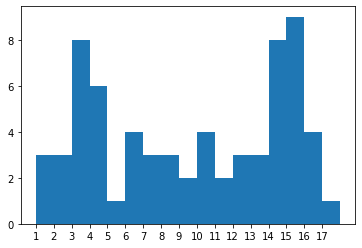

In [ ]:
# plt.hist(unique_day_counts, bins=range(1, unique_day_counts.max()+2))
# plt.xticks(range(1, unique_day_counts.max()+1))
# plt.show()


In [ ]:
# exact_7_days = (unique_day_counts == 7).sum()
# more_than_14_days = (unique_day_counts >= 14).sum()
# less_than_14_days = ((unique_day_counts < 14) & (unique_day_counts > 7)).sum()

# print(f"Number of unique_day_counts with exactly 7 days: {exact_7_days}")
# print(f"Number of unique_day_counts with 14 or more days: {more_than_14_days}")
# print(f"Number of unique_day_counts with less than 14 days: {less_than_14_days}")


Number of unique_day_counts with exactly 7 days: 3
Number of unique_day_counts with 14 or more days: 22
Number of unique_day_counts with less than 14 days: 17


In [ ]:
# days_saved = ((unique_day_counts < 8) & (unique_day_counts >= 3)).sum()

# print(f"Number of unique_day_counts with 4<=x<=7 days: {days_saved}")


Number of unique_day_counts with 4<=x<=7 days: 22


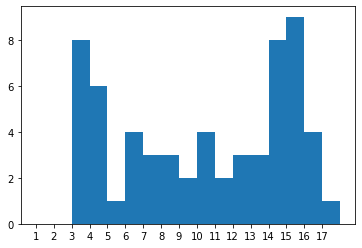

In [ ]:
# # validate filtering:
# # Group by RegistrationCode and count the number of unique days using the index level 'Day'
# unique_day_counts_after = log_date.groupby('RegistrationCode').apply(lambda x: x.index.get_level_values('Day').nunique())
# plt.hist(unique_day_counts_after, bins=range(1, unique_day_counts_after.max()+2))
# plt.xticks(range(1, unique_day_counts_after.max()+1))
# plt.show()

In [ ]:
# Validate filtering:
# Group by RegistrationCode and count the number of unique days using the 'Date' index level
unique_day_counts_after = log_date.groupby('RegistrationCode').apply(
    lambda x: pd.to_datetime(x.index.get_level_values('Date')).normalize().nunique()
)

# Plot histogram of the unique day counts
plt.hist(unique_day_counts_after, bins=range(1, unique_day_counts_after.max() + 2))
plt.xticks(range(1, unique_day_counts_after.max() + 1))
plt.show()


In [ ]:
# log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().describe()
# # max_calories_registration_code = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().idxmax()[0]
# # print(max_calories_registration_code)


count     605.000000
mean     1724.918790
std       666.498874
min       501.992000
25%      1240.670000
50%      1661.934976
75%      2116.812000
max      3952.681997
Name: Energy, dtype: float64

In [ ]:
# log_date.reset_index()["RegistrationCode"].nunique()

61

In [ ]:
# log_date['total_energy_per_day']

RegistrationCode  Day         food_id  Hour  
3002243           2023-06-25  103022    12:02    1875.019
                              103615    12:02    1875.019
                              100068    14:07    1875.019
                              101650    14:07    1875.019
                              101910    14:07    1875.019
                                                   ...   
3976912           2020-11-28  105645    19:43     977.350
                              104323    20:59     977.350
                                        20:59     977.350
                              105458    20:59     977.350
                                        20:59     977.350
Name: total_energy_per_day, Length: 8743, dtype: float64

In [ ]:
# nutr_list_no_energy = [nutrient for nutrient in nutr_list if nutrient != "Energy"]
# relative_nutrients = log_date[nutr_list_no_energy].div(log_date['total_energy_per_day'], axis=0)
# # relative_nutrients.to_pickle('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/relative_nutrients.pkl')

In [ ]:
# log_date[nutr_list_no_energy] = relative_nutrients

In [ ]:
# log_day = log_date.groupby(['RegistrationCode', 'Day'])[nutr_list].sum()
# log_day = log_day[log_day['Energy']>500]
# log_day = log_day[log_day['Energy']<4000]
# log_day

Protein  Total lipid (fat)  \
RegistrationCode Day                                       
3002243          2023-06-25  0.035344           0.046972   
                 2023-06-26  0.049002           0.044943   
                 2023-06-27  0.038459           0.031670   
                 2023-06-28  0.080478           0.037032   
3002905          2023-03-17  0.073231           0.035044   
...                               ...                ...   
3976912          2020-11-24  0.117572           0.022191   
                 2020-11-25  0.079731           0.052724   
                 2020-11-26  0.072963           0.053383   
                 2020-11-27  0.079164           0.036906   
                 2020-11-28  0.095187           0.028791   

                             Carbohydrate, by difference       Energy  \
RegistrationCode Day                                                    
3002243          2023-06-25                     0.109963  1875.019000   
                 2023-06-26                     0.103444  1790.800000   
                 2023-06-27                     0.133437  1755.283500   
                 2023-06-28                     0.085166  1701.610000   
3002905          2023-03-17                     0.096576  1080.651301   
...                                                  ...          ...   
3976912          2020-11-24                     0.107849   793.650000   
                 2020-11-25                     0.053607  1625.310000   
                 2020-11-26                     0.052958  1482.300000   
                 2020-11-27                     0.087597   931.755000   
                 2020-11-28                     0.095776   977.350000   

                             Alcohol, ethyl     Water  Fiber, total dietary  \
RegistrationCode Day                                                          
3002243          2023-06-25         0.00000  0.562251              0.010072   
                 2023-06-26         0.00000  0.490787              0.008634   
                 2023-06-27         0.00467  0.870281              0.014311   
                 2023-06-28         0.00000  0.634411              0.009088   
3002905          2023-03-17         0.00000  0.844686              0.015590   
...                                     ...       ...                   ...   
3976912          2020-11-24         0.00000  3.145007              0.012247   
                 2020-11-25         0.00000  1.627431              0.006740   
                 2020-11-26         0.00000  1.215015              0.009667   
                 2020-11-27         0.00000  2.677658              0.004765   
                 2020-11-28         0.00000  1.900892              0.013659   

                             Calcium, Ca  Iron, Fe  Magnesium, Mg  ...  \
RegistrationCode Day                                               ...   
3002243          2023-06-25     0.488385  0.005562       0.138842  ...   
                 2023-06-26     0.348758  0.008101       0.178452  ...   
                 2023-06-27     0.547081  0.007146       0.181259  ...   
                 2023-06-28     0.429546  0.010115       0.157386  ...   
3002905          2023-03-17     0.508037  0.007400       0.251391  ...   
...                                  ...       ...            ...  ...   
3976912          2020-11-24     1.612361  0.011130       0.286839  ...   
                 2020-11-25     0.849278  0.005580       0.171198  ...   
                 2020-11-26     0.624705  0.005240       0.143358  ...   
                 2020-11-27     2.063901  0.005291       0.223981  ...   
                 2020-11-28     0.959968  0.003072       0.209802  ...   

                             Campesterol  Fluoride, F   Glucose  \
RegistrationCode Day                                              
3002243          2023-06-25     0.156150     1.398452  0.002791   
                 2023-06-26     0.046314     0.223361  0.022499   
                 2023-06-27     0.051896

In [ ]:
# log_day['pct_protein_calories'] = (log_day['Protein']*4) * 100
# log_day['pct_carb_calories'] = (log_day['Carbohydrate, by difference']*4) * 100
# log_day['pct_fat_calories'] = (log_day['Total lipid (fat)']*9) * 100
# log_day['pct_alcohol_calories'] = (log_day['Alcohol, ethyl']*7) * 100
# log_day

Protein  Total lipid (fat)  \
RegistrationCode Day                                       
3002243          2023-06-25  0.035344           0.046972   
                 2023-06-26  0.049002           0.044943   
                 2023-06-27  0.038459           0.031670   
                 2023-06-28  0.080478           0.037032   
3002905          2023-03-17  0.073231           0.035044   
...                               ...                ...   
3976912          2020-11-24  0.117572           0.022191   
                 2020-11-25  0.079731           0.052724   
                 2020-11-26  0.072963           0.053383   
                 2020-11-27  0.079164           0.036906   
                 2020-11-28  0.095187           0.028791   

                             Carbohydrate, by difference       Energy  \
RegistrationCode Day                                                    
3002243          2023-06-25                     0.109963  1875.019000   
                 2023-06-26                     0.103444  1790.800000   
                 2023-06-27                     0.133437  1755.283500   
                 2023-06-28                     0.085166  1701.610000   
3002905          2023-03-17                     0.096576  1080.651301   
...                                                  ...          ...   
3976912          2020-11-24                     0.107849   793.650000   
                 2020-11-25                     0.053607  1625.310000   
                 2020-11-26                     0.052958  1482.300000   
                 2020-11-27                     0.087597   931.755000   
                 2020-11-28                     0.095776   977.350000   

                             Alcohol, ethyl     Water  Fiber, total dietary  \
RegistrationCode Day                                                          
3002243          2023-06-25         0.00000  0.562251              0.010072   
                 2023-06-26         0.00000  0.490787              0.008634   
                 2023-06-27         0.00467  0.870281              0.014311   
                 2023-06-28         0.00000  0.634411              0.009088   
3002905          2023-03-17         0.00000  0.844686              0.015590   
...                                     ...       ...                   ...   
3976912          2020-11-24         0.00000  3.145007              0.012247   
                 2020-11-25         0.00000  1.627431              0.006740   
                 2020-11-26         0.00000  1.215015              0.009667   
                 2020-11-27         0.00000  2.677658              0.004765   
                 2020-11-28         0.00000  1.900892              0.013659   

                             Calcium, Ca  Iron, Fe  Magnesium, Mg  ...  \
RegistrationCode Day                                               ...   
3002243          2023-06-25     0.488385  0.005562       0.138842  ...   
                 2023-06-26     0.348758  0.008101       0.178452  ...   
                 2023-06-27     0.547081  0.007146       0.181259  ...   
                 2023-06-28     0.429546  0.010115       0.157386  ...   
3002905          2023-03-17     0.508037  0.007400       0.251391  ...   
...                                  ...       ...            ...  ...   
3976912          2020-11-24     1.612361  0.011130       0.286839  ...   
                 2020-11-25     0.849278  0.005580       0.171198  ...   
                 2020-11-26     0.624705  0.005240       0.143358  ...   
                 2020-11-27     2.063901  0.005291       0.223981  ...   
                 2020-11-28     0.959968  0.003072       0.209802  ...   

                             Lycopene  Phytosterols    Starch   omega_6  \
RegistrationCode Day                                                      
3002243          2023-06-25  3.537884      0.413625  0.075583  0.013899   
                 2023-06-26  0.640902      0.165060  0.041207  0.020654   
        

In [ ]:
# log_day['sat_to_total_lipids_ratio'] = log_day['Fatty acids, total saturated'] / log_day['Total lipid (fat)']
# log_day['trans_to_total_lipids_ratio'] = log_day['Fatty acids, total trans'] / log_day['Total lipid (fat)']
# log_day['mono_to_total_lipids_ratio'] = log_day['Fatty acids, total monounsaturated'] / log_day['Total lipid (fat)']
# log_day['poly_to_total_lipids_ratio'] = log_day['Fatty acids, total polyunsaturated'] / log_day['Total lipid (fat)']
# log_day['omega3_to_total_lipids_ratio'] = log_day['omega_3'] / log_day['Total lipid (fat)']
# log_day['omega6_to_total_lipids_ratio'] = log_day['omega_6'] / log_day['Total lipid (fat)']

# # Compute and cap omega6_to_omega3_ratio at 100
# log_day['omega6_to_omega3_ratio'] = (
#     log_day['omega_6'] / log_day['omega_3'].replace(0, np.nan)
# ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(upper=100)

# log_day['pct_saturated_fat_calories'] = (log_day['Fatty acids, total saturated']*9) * 100
# log_day['pct_saturated_fat_calories']


RegistrationCode  Day       
3002243           2023-06-25    30729.680140
                  2023-06-26    18760.814972
                  2023-06-27    22640.052544
                  2023-06-28    20266.532861
3002905           2023-03-17     7419.723095
                                    ...     
3976912           2020-11-24     6464.339893
                  2020-11-25    26856.900181
                  2020-11-26    25044.120222
                  2020-11-27    14627.029305
                  2020-11-28     8621.977560
Name: pct_saturated_fat_calories, Length: 605, dtype: float64

In [ ]:
# log_day = log_day.join(subjects_df[["age", "gender"]])
# log_day = log_day.reset_index(level=[1], drop=True)
# log_day = log_day.dropna()
# log_day

Protein  Total lipid (fat)  \
RegistrationCode Date                                        
3002905          2023-01-01   79.137673          37.870467   
                 2023-01-01  113.249134          41.320884   
                 2023-01-01  103.891549          50.321934   
                 2023-01-01   77.807899          53.404300   
                 2023-01-01   54.675249          40.650700   
...                                 ...                ...   
3976912          2020-01-01   93.311001          17.612000   
                 2020-01-01  129.587802          85.692601   
                 2020-01-01  108.152502          79.128997   
                 2020-01-01   73.761851          34.387600   
                 2020-01-01   93.030750          28.139000   

                             Carbohydrate, by difference       Energy  \
RegistrationCode Date                                                   
3002905          2023-01-01                   104.364990  1080.651301   
                 2023-01-01                   412.858615  2467.873131   
                 2023-01-01                   203.076833  1659.235000   
                 2023-01-01                   212.879900  1613.630000   
                 2023-01-01                   161.415150  1200.330000   
...                                                  ...          ...   
3976912          2020-01-01                    85.594001   793.650000   
                 2020-01-01                    87.127300  1625.310000   
                 2020-01-01                    78.499502  1482.300000   
                 2020-01-01                    81.618651   931.755000   
                 2020-01-01                    93.606499   977.350000   

                             Alcohol, ethyl        Water  \
RegistrationCode Date                                      
3002905          2023-01-01             0.0   912.810903   
                 2023-01-01             0.0  1222.639520   
                 2023-01-01             0.0   916.110495   
                 2023-01-01             0.0  1224.889106   
                 2023-01-01             0.0   759.720088   
...                                     ...          ...   
3976912          2020-01-01             0.0  2496.034962   
                 2020-01-01             0.0  2645.079454   
                 2020-01-01             0.0  1801.016971   
                 2020-01-01             0.0  2494.921197   
                 2020-01-01             0.0  1857.836478   

                             Fiber, total dietary  Calcium, Ca   Iron, Fe  \
RegistrationCode Date                                                       
3002905          2023-01-01             16.846950   549.010896   7.996322   
                 2023-01-01             32.184401  2893.975133  54.569111   
                 2023-01-01             17.851000  1083.139100  14.441373   
                 2023-01-01             22.915000  1381.220000  11.800800   
                 2023-01-01             20.956000   984.610000   6.802250   
...                                           ...          ...        ...   
3976912          2020-01-01              9.720000  1279.650002   8.833000   
                 2020-01-01             10.954000  1380.340000   9.068700   
                 2020-01-01             14.330000   926.000000   7.767500   
                 2020-01-01              4.440000  1923.050000   4.929450   
                 2020-01-01             13.350000   938.225000   3.002500   

                             Magnesium, Mg  ...  sat_to_total_lipids_ratio  \
RegistrationCode Date                       ...                              
3002905          2023-01-01     271.666435  ...                   0.217693   
                 2023-01-01     885.646601  ...                   0.314461   
                 2023-01-01     351.019301  ...                   0.348482   
                 2023-01-01     407.339999  ...                   0.358929   
                 2023-01

In [ ]:
# # Step 1: Reset index and drop "Day"
# log_reset = log_day.reset_index().drop("Date", axis=1)

# # Group by RegistrationCode and calculate mean for all numeric columns
# log_grouped = log_reset.groupby('RegistrationCode').mean()
# log_grouped.head()

,Protein,Total lipid (fat),"Carbohydrate, by difference",Energy,"Alcohol, ethyl",Water,"Fiber, total dietary","Calcium, Ca","Iron, Fe","Magnesium, Mg",...,sat_to_total_lipids_ratio,trans_to_total_lipids_ratio,mono_to_total_lipids_ratio,poly_to_total_lipids_ratio,omega3_to_total_lipids_ratio,omega6_to_total_lipids_ratio,omega6_to_omega3_ratio,pct_saturated_fat_calories,age,gender
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002905,87.351736,50.069312,206.347397,1604.006195,0.000000,911.458508,25.858398,1260.485766,16.645325,421.281375,...,0.336009,0.016637,0.348066,0.212510,0.035386,0.288796,8.437844,15205.662549,68.0,0.0
3014896,92.849009,104.566135,193.533605,2091.544339,2.624800,687.594852,15.526340,693.055799,12.751012,300.797266,...,0.310236,0.008477,0.516071,0.223154,0.022265,0.220577,10.499763,28249.547000,56.0,1.0
3026711,76.476997,86.199248,220.601815,1968.269951,1.685782,568.066505,15.743847,484.214182,11.107912,253.131151,...,0.349698,0.005899,0.389095,0.239282,0.023074,0.219122,12.763148,25824.611266,57.0,0.0
3074002,67.680174,59.486267,223.012688,1766.474607,13.147000,1076.966475,19.143062,864.018974,13.019091,554.885546,...,0.331090,0.006619,0.401217,0.212370,0.024180,0.264278,13.180283,17443.070857,64.0,0.0
3102388,42.989047,50.390021,97.741605,1020.555756,0.000000,304.154176,11.831342,256.828482,7.382523,119.320917,...,0.399187,0.014498,0.331165,0.267793,0.035869,0.270620,8.626429,17534.972857,40.0,1.0
3103223,74.265734,128.808057,218.318977,2542.201744,30.110876,896.715746,7.054583,544.659721,8.287844,223.620249,...,0.645970,0.003847,0.379769,0.229569,0.023249,0.217709,10.255272,68200.025261,58.0,0.0
3114331,63.422525,91.886953,251.414001,2074.861615,0.258750,981.965386,22.637229,708.581708,12.911842,281.668381,...,0.555694,0.008221,0.352435,0.205352,0.030119,0.252208,8.829956,45530.184201,25.0,0.0
3132969,131.437048,105.336394,293.771951,2649.147987,7.183300,1792.837563,37.729554,1265.084135,25.621004,450.969467,...,0.360290,0.018386,0.391867,0.139126,0.012374,0.174754,15.103710,34363.452182,56.0,1.0
3144762,57.051716,52.221782,189.202271,1489.489334,7.055824,1045.085569,16.684761,625.402744,9.240443,289.003822,...,0.353140,0.013384,0.343644,0.231184,0.029654,0.283965,11.578656,16363.940398,70.0,1.0


In [63]:
# diet_by_person = log_grouped.drop(columns=['Protein', 'Carbohydrate, by difference', 'Total lipid (fat)', 'Alcohol, ethyl', 'Fatty acids, total saturated', 'total_energy_per_day'])
# diet_by_person.head()

In [ ]:
# diet_by_person.isnull().sum().sort_values()

Energy              0
Sugar alcohols      0
Biotin              0
Ash                 0
Betaine             0
                   ..
Pantothenic acid    0
Selenium, Se        0
Choline, total      0
Fructose            0
gender              0
Length: 61, dtype: int64

### END

In [24]:
baseline_foods_all

,RegistrationCode,Acai,Actimel,Agave Syrup,Alaska pollock,Alfajores,Alfalfa sprouts,Alfredo Sauce,Almond Beverage,Almond Cake,...,Zucchini Fritters,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,garlic paste,ginger,kale,pumpkin soup,sucra light
0,111527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01552
1,117111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,126092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,981727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.84,NaN,NaN,NaN
221,988899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,992638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,997427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
baseline_foods_all = baseline_foods_all.set_index('RegistrationCode')
baseline_foods = baseline_foods_all[[col for col in all_features_10k if col in baseline_foods_all.columns]]

In [ ]:
# Normalize by person to get mean % of daily calories
baseline_foods = baseline_foods.fillna(0)
baseline_foods = baseline_foods.div(baseline_foods.sum(axis=1), axis=0)
baseline_foods

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,Yogurt,Zucchini,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,ginger,kale,Water,Fructose
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000478,0.000473,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,0.000000,0.000015,0.000000,0.0,0.0,0.001029,0.0,0.000013,0.0,0.0
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.002679,0.0,0.000000,0.0,0.0
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,0.000000,0.000055,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,0.000000,0.000000,0.001403,0.0,0.0,0.025742,0.0,0.000000,0.0,0.0
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [ ]:
# baseline_nutrients = baseline_nutrients.set_index('RegistrationCode').drop(['Main score'], axis=1)
# baseline_nutrients

In [ ]:
# # Dictionary with the mappings for renaming
# rename_dict = {
#     'Fructose': 'Fructose',
#     'caffeine_mg': 'Caffeine',
#     'calcium_mg': 'Calcium, Ca',
#     'carbohydrate_g': 'Carbohydrate, by difference',
#     'cholesterol_mg': 'Cholesterol',
#     'iron_mg': 'Iron, Fe',
#     'magnesium_mg': 'Magnesium, Mg',
#     'niacin_mg': 'Niacin',
#     'phosphorus_mg': 'Phosphorus, P',
#     'potassium_mg': 'Potassium, K',
#     'protein_g': 'Protein',
#     'raevitamina_ug': 'Vitamin A, RAE',
#     'riboflavin_mg': 'Riboflavin',
#     'sodium_mg': 'Sodium, Na',
#     'thiamin_mg': 'Thiamin',
#     'totaldietaryfiber_g': 'Fiber, total dietary',
#     'totalfolate_ug': 'Folate, total',
#     'totallipid_g': 'Total lipid (fat)',
#     'totalmonounsaturatedfattyacids_g': 'Fatty acids, total monounsaturated',
#     'totalpolyunsaturatedfattyacids_g': 'Fatty acids, total polyunsaturated',
#     'totalsaturatedfattyacids_g': 'Fatty acids, total saturated',
#     'vitaminb12_ug': 'Vitamin B-12',
#     'vitaminb6_mg': 'Vitamin B-6',
#     'vitaminc_mg': 'Vitamin C, total ascorbic acid',
#     'vitamind_iu': 'Vitamin D (D2 + D3)',
#     'vitamine_mg': 'vitamin_E',
#     'zinc_mg': 'Zinc, Zn'
# }

# # Rename the items in the list using the mapping
# baseline_nutrients.columns = [rename_dict.get(item, item) for item in baseline_nutrients.columns]

# baseline_nutrients


In [30]:
# food_cat_baseline = food_cat_baseline.set_index('RegistrationCode')
# # Normalize by person to get mean % of daily calories
# food_cat_baseline = food_cat_baseline.div(food_cat_baseline.sum(axis=1), axis=0)
# food_cat_baseline

## Combine Dataframes

In [31]:
# baseline_nutrients = baseline_nutrients.set_index('RegistrationCode')
# baseline_nutrients.columns = [rename_dict.get(item, item) for item in baseline_nutrients.columns]
# baseline_nutrients

In [ ]:
# diet_mb = baseline_foods.join(baseline_nutrients, how='inner')
# # diet_mb = diet_mb.dropna()
# diet_mb

In [33]:
subjects_df = subjects_df.reset_index(level=[1], drop=True)

In [34]:
subjects_df

,StudyTypeID,city,country,gender,month_of_birth,us_state,yob,StudyTypeID2,StudyTypeID3,StudyTypeID4,StudyTypeID5,StudyTypeID6,StudyTypeID7,StudyTypeID8,StudyTypeID9,age,tz
RegistrationCode,,,,,,,,,,,,,,,,,
111527,3.0,None,IL,0.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,46.0,Asia/Jerusalem
117111,3.0,None,IL,1.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,47.0,Asia/Jerusalem
126092,3.0,None,IL,0.0,None,None,1962.0,NaN,None,None,None,None,None,None,None,56.0,Asia/Jerusalem
12752,3.0,None,IL,1.0,None,None,1962.0,NaN,None,None,None,None,None,None,None,56.0,Asia/Jerusalem
128811,3.0,None,IL,1.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,46.0,Asia/Jerusalem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988899,3.0,None,IL,1.0,None,None,1981.0,NaN,None,None,None,None,None,None,None,36.0,Asia/Jerusalem
991569,3.0,None,IL,1.0,None,None,1966.0,NaN,None,None,None,None,None,None,None,51.0,Asia/Jerusalem
992638,3.0,None,IL,1.0,None,None,1964.0,NaN,None,None,None,None,None,None,None,53.0,Asia/Jerusalem


In [ ]:
base_features = ["age", "gender"]
subjects_df.index = subjects_df.index.astype('int')
baseline_foods = baseline_foods.join(subjects_df[base_features])
baseline_foods = baseline_foods.rename(columns={'gender': 'sex'})
# diet_mb = diet_mb.reset_index(level=[1], drop=True)
# diet_mb = diet_mb.dropna()
baseline_foods

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,ginger,kale,Water,Fructose,age,sex
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,46.0,0.0
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,47.0,1.0
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,0.000000,0.0,0.0,0.001029,0.0,0.000013,0.0,0.0,56.0,0.0
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.002679,0.0,0.000000,0.0,0.0,56.0,1.0
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,56.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,0.001403,0.0,0.0,0.025742,0.0,0.000000,0.0,0.0,61.0,1.0
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,36.0,1.0
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,53.0,1.0


In [ ]:
aus_diet_features = baseline_foods.columns
aus_diet_features

Index(['Alfalfa sprouts', 'Almond Beverage', 'Almond spread', 'Almonds',
       'Amba', 'Apple', 'Apple Cake', 'Apple juice', 'Apricot', 'Apropo',
       ...
       'Zucchini Patties', 'black pepper', 'dried tomato spread',
       'emmer wheat bread', 'ginger', 'kale', 'Water', 'Fructose', 'age',
       'sex'],
      dtype='object', length=526)

In [ ]:
aus_10k_shared_features = [col for col in aus_diet_features if col in all_features_10k]
aus_10k_shared_features.remove('Fructose')
aus_10k_shared_features

['Alfalfa sprouts',
 'Almond Beverage',
 'Almond spread',
 'Almonds',
 'Amba',
 'Apple',
 'Apple Cake',
 'Apple juice',
 'Apricot',
 'Apropo',
 'Artichoke',
 'Arugula',
 'Asparagus',
 'Avocado',
 'Avocado Sandwich',
 'Bagel',
 'Baguette',
 'Baked apple',
 'Baklava',
 'Balsamic vinegar',
 'Bamba',
 'Banana',
 'Banana Cake',
 'Barbecue sauce',
 'Barley soup',
 'Basil',
 'Bean soup',
 'Beans black-eyed peas',
 'Beef',
 'Beef Cholent',
 'Beef Lasagna',
 'Beef Shawarma',
 'Beer',
 'Beet',
 'Beet Salad',
 'Biscuit',
 'Bissli',
 'Black beans',
 'Blintzes',
 'Blueberries',
 'Boiled corn',
 'Bolognese',
 'Brazil nuts',
 'Bread',
 'Bread Crumbs',
 'Broccoli',
 'Broth',
 'Brown Rice',
 'Brown Sugar',
 'Brownies',
 'Buckwheat crackers',
 'Bulgur',
 'Burekas',
 'Butter',
 'Butter Cookies',
 'Caesar Salad',
 'Cake',
 'Calamari',
 'Camembert or Brie',
 'Candies',
 'Canned Sardine',
 'Canned Tuna Fish',
 'Canned corn',
 'Cappuccino',
 'Carrot Cake',
 'Carrot Juice',
 'Carrot Salad',
 'Carrots',
 'Cash

In [ ]:
len(aus_10k_shared_features)

525

In [ ]:
baseline_foods = baseline_foods[aus_10k_shared_features]

In [40]:
baseline_mb.index = baseline_mb.index.astype('int')
diet_mb_baseline = baseline_foods.join(baseline_mb)
diet_mb_baseline

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.0,0.0,0.0,0.013741,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.000000,-4.0,-4.000000,-2.316650,-4.0,-4.000000,-4.000000,110.0,2.69
117111,0.0,0.0,0.0,0.000000,0.000000,0.014040,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.000000,-4.0,-2.772134,-4.000000,-4.0,-4.000000,-4.000000,163.0,3.33
126092,0.0,0.0,0.0,0.004597,0.000000,0.004053,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.000000,-4.0,-4.000000,-3.098488,-4.0,-4.000000,-2.382134,184.0,3.32
12752,0.0,0.0,0.0,0.005557,0.000000,0.007999,0.000000,0.0,0.000000,0.0,...,-4.000000,-3.635983,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-2.999455,107.0,2.20
130279,0.0,0.0,0.0,0.003899,0.000000,0.020388,0.000000,0.0,0.000000,0.0,...,-3.743862,-4.000000,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,159.0,1.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.0,0.0,0.0,0.000000,0.000000,0.003048,0.021718,0.0,0.000000,0.0,...,-4.000000,-3.071785,-4.0,-2.884203,-4.000000,-4.0,-4.000000,-4.000000,260.0,4.07
988899,0.0,0.0,0.0,0.000000,0.000518,0.001211,0.000000,0.0,0.000000,0.0,...,-4.000000,-3.090213,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,146.0,2.38
992638,0.0,0.0,0.0,0.000000,0.000000,0.004343,0.000000,0.0,0.000627,0.0,...,-4.000000,-3.560856,-4.0,-4.000000,-4.000000,-4.0,-3.780138,-4.000000,167.0,2.50


In [ ]:
# Baseline dataframe is already created in cell 42
diet_mb_baseline

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-4.000000,-4.000000,-2.508685,-4.0,-4.000000,-4.000000,149.0,3.46
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-3.327926,-2.345744,-4.000000,-4.0,-4.000000,-4.000000,217.0,3.93
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,-4.000000,-4.000000,-4.000000,-4.000000,-2.595642,-4.0,-4.000000,-2.013733,199.0,3.94
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,-4.000000,-3.140830,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-2.458283,209.0,3.97
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,-2.593218,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-3.760075,-4.000000,198.0,2.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,-4.000000,-2.852334,-4.000000,-2.330696,-4.000000,-4.0,-4.000000,-4.000000,263.0,3.97
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,-4.000000,-3.575834,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,190.0,2.10
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,145.0,2.22


In [ ]:
# Baseline data shape
print(diet_mb_baseline.shape)

(225, 1251)
(225, 1251)


In [ ]:
# from sklearn.preprocessing import StandardScaler

# with open(home_path + f'data/{SPECIES}/age_scaler.pkl', 'rb') as f:
#     age_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/mb_scaler.pkl', 'rb') as f:
#     mb_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/div_scaler.pkl', 'rb') as f:
#     div_scaler = pickle.load(f)

# diet_scaler = StandardScaler()
# diet_mb_10k_scaled = diet_scaler.fit_transform(diet_mb_10k[aus_10k_shared_features])

# # # Apply the scaler to the dataframe
# diet_mb_baseline.loc[:, aus_10k_shared_features] = diet_scaler.transform(diet_mb_baseline[aus_10k_shared_features])
# diet_mb_baseline.loc[:, ["age"]] = age_scaler.transform(diet_mb_baseline[["age"]])
# diet_mb_baseline.loc[:, targets_10k] = mb_scaler.transform(diet_mb_baseline[targets_10k])
# diet_mb_baseline.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_baseline[["Richness", "Shannon_diversity"]])
# # diet_mb_baseline[aus_10k_shared_features] = pd.DataFrame(scaler.transform(diet_mb_baseline[aus_10k_shared_features]), columns=diet_mb_baseline[aus_10k_shared_features].columns, index=diet_mb_baseline[aus_10k_shared_features].index)
# diet_mb_baseline.describe()

In [ ]:
# Scaling code for baseline (commented out)
# diet_mb_baseline.loc[:, aus_10k_shared_features] = diet_scaler.transform(diet_mb_baseline[aus_10k_shared_features])
# diet_mb_baseline.loc[:, ["age"]] = age_scaler.transform(diet_mb_baseline[["age"]])
# diet_mb_baseline.loc[:, targets_10k] = mb_scaler.transform(diet_mb_baseline[targets_10k])
# diet_mb_baseline.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_baseline[["Richness", "Shannon_diversity"]])
# diet_mb_baseline.describe()

In [ ]:
# Count rows that have at least one NaN
nan_rows = diet_mb_baseline[diet_mb_baseline.isna().any(axis=1)]
num_nan_rows = len(nan_rows)

# Find which columns contain NaN values
nan_features = diet_mb_baseline.columns[diet_mb_baseline.isna().any()].tolist()

print(f"Number of rows with at least one NaN: {num_nan_rows}")
print("Features that contain NaN values:")
print(nan_features)


Number of rows with at least one NaN: 37
Features that contain NaN values:
['age', 'sex', 'fBin__100|gBin__473|sBin__693', 'fBin__100|gBin__473|sBin__694', 'fBin__100|gBin__474|sBin__695', 'fBin__100|gBin__477|sBin__698', 'fBin__100|gBin__481|sBin__704', 'fBin__100|gBin__481|sBin__705', 'fBin__100|gBin__481|sBin__706', 'fBin__100|gBin__483|sBin__709', 'fBin__102|gBin__490|sBin__720', 'fBin__102|gBin__490|sBin__721', 'fBin__102|gBin__490|sBin__722', 'fBin__103|gBin__491|sBin__727', 'fBin__104|gBin__493|sBin__730', 'fBin__104|gBin__494|sBin__731', 'fBin__104|gBin__495|sBin__732', 'fBin__104|gBin__496|sBin__733', 'fBin__104|gBin__496|sBin__734', 'fBin__104|gBin__498|sBin__736', 'fBin__104|gBin__500|sBin__738', 'fBin__108|gBin__515|sBin__766', 'fBin__108|gBin__515|sBin__767', 'fBin__108|gBin__517|sBin__769', 'fBin__108|gBin__521|sBin__773', 'fBin__108|gBin__523|sBin__776', 'fBin__108|gBin__525|sBin__778', 'fBin__108|gBin__526|sBin__779', 'fBin__108|gBin__531|sBin__787', 'fBin__121|gBin__56

In [ ]:
print("\nNaN count per column:")
print(diet_mb_baseline.isna().sum()[diet_mb_baseline.isna().sum() > 0])
diet_mb_baseline = diet_mb_baseline.dropna(how='any')



NaN count per column:
age                               2
sex                               2
fBin__100|gBin__473|sBin__693    36
fBin__100|gBin__473|sBin__694    36
fBin__100|gBin__474|sBin__695    36
                                 ..
fBin__97|gBin__462|sBin__676     36
fBin__97|gBin__462|sBin__678     36
fBin__99|gBin__469|sBin__687     36
Richness                         36
Shannon_diversity                36
Length: 728, dtype: int64


In [ ]:
print(diet_mb_baseline.shape)

(188, 1251)
(188, 1251)


In [ ]:
diet_mb_baseline.to_pickle(home_path + f'data/diet_mb_{study_name.lower()}_baseline.pkl')
with open(home_path + f'data/my_lists_{study_name.lower()}.pkl', 'wb') as file:
    pickle.dump([aus_10k_shared_features, targets_10k], file)

In [ ]:
print(len(aus_10k_shared_features))
print(len(targets_10k))

525
724
